<a href="https://colab.research.google.com/github/Cairo-Henrique/Network-Value-Investing/blob/main/Portfolio_Optimization_with_PMFG_and_Markowitz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Portfolio Selection and Optimization Algorithm via Network Theory and Markowitz**

This notebook implements an advanced portfolio construction strategy, utilizing topological graph filtering and centrality metrics to mitigate systemic risk within the stock market.

---

## **1. Selection Methodology**

This algorithm follows three fundamental stages:

### **A. Topological Filtering (PMFG)**

The raw correlation matrix is filtered using the **Planar Maximally Filtered Graph (PMFG)** algorithm. This technique extracts the "skeleton" of the market's strongest connections while maintaining graph planarity. This allows for the identification of sector clusters and essential connections that the raw matrix often obscures.

### **B. Centrality Selection (Investing in the Periphery)**

We use the **Node Strength** (Weighted Degree) metric as a centrality measure in relation to the network. The algorithm selects assets with the **lowest centrality**.

* **Thesis:** "Central" assets (Hubs) carry high systemic risk and tend to collapse together during crises. "Peripheral" assets offer genuine diversification and protection against contagion.

### **C. Robust Optimization**

To avoid excessive concentration, we choose the max Sharpe or min volatility portfolio via efficient frontier optimization to define final weights.

---

## **2. Notebook Workflow**

1. **Data Ingestion:** Download of B3 tickers via `yfinance`.
2. **Filtering:** Construction of the PMFG graph and noise removal from the correlation matrix.
3. **Network Analysis:** Calculation of centrality metrics and identification of "Core" and "Periphery."
4. **Optimization:** Generation of Maximum Sharpe and Minimum Volatility portfolios.
5. **Backtest:** Comparison of accumulated performance against **IBOVESPA** and **CDI**.

---

## **3. Libraries Used**

* `PyPortfolioOpt`: For Efficient Frontier and HRP calculations.
* `NetworkX`: For construction and topological analysis of the PMFG graph.
* `yfinance`: For obtaining historical data.
* `pandas` & `numpy`: For time-series processing.
* `matplotlib` & `seaborn`: For data and network visualization.
* `requests`: To access the Central Bank (BCB) API.

---

### **How to Use**

1. Execute the dependency installation cells.
2. Define the analysis period in the parameters section.
3. The final graph will display a comparison of R$ 1.00 invested in the strategy versus the benchmarks.

In [ ]:
!pip install PyPortfolioOpt

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting
import requests
from datetime import datetime, timedelta

# Parameters



In [ ]:
# --- Define Tickers with many stocks ---
tickers = [
    "ITUB4.SA", "BBDC4.SA", "BBAS3.SA", "SANB11.SA", "BPAC11.SA",
    "ITSA4.SA", "BBSE3.SA", "PSSA3.SA", "CXSE3.SA", "B3SA3.SA",
    "VALE3.SA", "PETR4.SA", "PETR3.SA", "PRIO3.SA", "RECV3.SA",
    "VBBR3.SA", "UGPA3.SA", "CSNA3.SA", "GGBR4.SA", "GOAU4.SA",
    "ELET3.SA", "CPLE6.SA", "CMIG4.SA", "EQTL3.SA", "EGIE3.SA",
    "TRPL4.SA", "TAEE11.SA", "ENGI11.SA", "CPFE3.SA", "SBSP3.SA",
    "CSMG3.SA", "SAPR11.SA", "ABEV3.SA", "JBSS3.SA", "BRFS3.SA",
    "BEEF3.SA", "SMTO3.SA", "ASAI3.SA", "CRFB3.SA", "RADL3.SA",
    "HAPV3.SA", "RDOR3.SA", "WEGE3.SA", "EMBR3.SA", "POMO4.SA",
    "RENT3.SA", "MOVI3.SA", "RAIL3.SA", "STBP3.SA", "TUPY3.SA",
    "LREN3.SA", "MGLU3.SA", "ARZZ3.SA", "PETZ3.SA", "ALOS3.SA",
    "CYRE3.SA", "MRVE3.SA", "DIRR3.SA", "VIVA3.SA", "TOTS3.SA",
    "VIVT3.SA", "TIMS3.SA", "LWSA3.SA", "MULT3.SA"
]

# --- Time periods for past data analysis ---
start_past_data = "2021-01-01"
end_past_data = "2023-12-31"

# --- Returns and risk models ---

# EXPECTED RETURNS MODELS (mu)
# Options:
# - "mean_historical_return": Traditional average daily returns.
# - "ema_historical_return": Exponential moving average (gives more weight to recent prices).
# - "capm_return": Uses the Capital Asset Pricing Model based on market returns.
ret_model = "ema_historical_return"

# RISK MODELS (S)
# Options:
# - "sample_cov": Standard sample covariance matrix (unfiltered noise).
# - "semicovariance": Focuses only on downside risk (volatility of negative returns).
# - "exp_cov": Exponentially weighted; gives more importance to recent volatility.
# - "ledoit_wolf": The standard shrinkage towards the average of all variances.
# - "ledoit_wolf_constant_variance": Shrinks towards a matrix with equal variance for all assets.
# - "ledoit_wolf_single_factor": Shrinks towards a Sharpe-style single-factor market model.
# - "ledoit_wolf_constant_correlation": Shrinks towards a matrix where all assets have the same correlation.
# - "oracle_approximating": OAS method; mathematically superior when assets >> data points.
risk_model = "ledoit_wolf_constant_correlation"

# --- Time periods for simulation ---

# Convert string end_past_data into a datetime object
end_past_dt = datetime.strptime(end_past_data, '%Y-%m-%d')

# Add 1 day for the simulation start
start_simulation_dt = end_past_dt + timedelta(days=1)
start_simulation = start_simulation_dt.strftime('%Y-%m-%d')

# Get yesterday's date for the simulation end
end_simulation_dt = datetime.now() - timedelta(days=1)
end_simulation = end_simulation_dt.strftime('%Y-%m-%d')

# **Correlation matrix of stock market**

[                       0%                       ]

Iniciando download...


[*********************100%***********************]  56 of 56 completed


Sucesso! Analisando 53 ativos (de 56 originais).


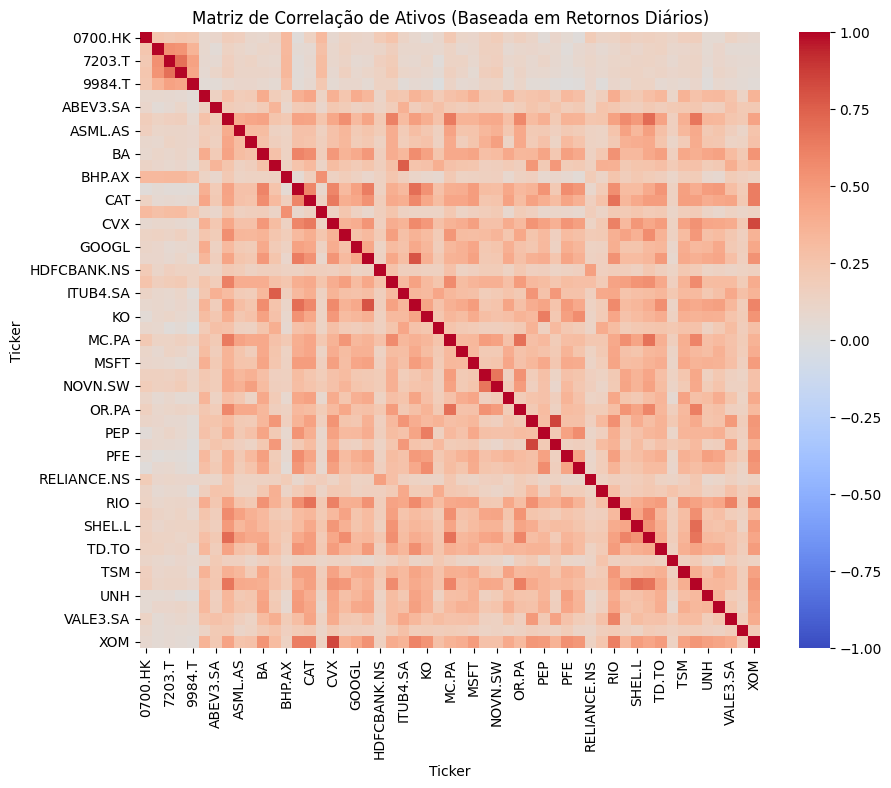

In [ ]:
def get_data(tickers, start, end):
    print("Iniciando download...")
    # auto_adjust=True evita o aviso de FutureWarning
    data = yf.download(tickers, start=start, end=end, auto_adjust=True)['Close']

    # 1. Drop stocks that are missing more than 10% of their data
    # (e.g., stocks that IPO'd recently or delisted)
    min_valid_days = int(data.shape[0] * 0.90)
    data = data.dropna(axis=1, thresh=min_valid_days)

    # 2. Forward-fill prices for illiquid days
    # (If it didn't trade today, the price is the same as yesterday)
    data = data.ffill()

    # 3. Drop any remaining rows with NaNs
    # (Usually just the very first row if the forward-fill had no prior data to grab)
    data = data.dropna()

    print(f"Sucesso! Analisando {data.shape[1]} ativos (de {len(tickers)} originais).")

    return data

data = get_data(tickers, start_past_data, end_past_data)

def calculate_correlation_matrix(data):
    # Calcular Retornos Diários
    # É crucial usar retornos (pct_change), não preços, para correlação real
    returns = data.pct_change().dropna()

    # Calcular Matriz de Correlação
    corr_matrix = returns.corr()

    return corr_matrix

corr_matrix = calculate_correlation_matrix(data)

# --- Exibição Visual (Heatmap) ---
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=False,       # Escreve o valor nos quadrados
            cmap='coolwarm',  # Cores: Vermelho (alta) a Azul (baixa)
            vmin=-1, vmax=1,  # Escala fixa de -1 a 1
            fmt=".2f",        # 2 casas decimais
            linewidths=0,
            )

plt.title("Matriz de Correlação de Ativos (Baseada em Retornos Diários)")
plt.show()

# **Complex Networks Stock Selection**

#### **Topological Filtering (PMFG)**

The raw correlation matrix of the market is often noisy due to temporary price movements. We apply the **Planar Maximally Filtered Graph (PMFG)** algorithm to extract the "backbone" of the market. Unlike a Minimum Spanning Tree (MST), the PMFG allows for loops and cliques, preserving the essential clustering structure of sectors while maintaining planarity.

* **Scientific Basis:** *Tumminello et al. (2005)* demonstrated that PMFG is a robust tool for filtering information in complex systems, providing a clearer view of the hierarchical structure of financial markets than raw matrices.

#### **Peripheral Asset Selection (Node Strength)**

Once the PMFG is constructed, we calculate the **Node Strength** (Weighted Degree Centrality) for each stock. We specifically target assets in the **periphery** of the network (those with the lowest centrality).

* **Why Periphery?** Research by *Pozzi, Di Matteo, and Aste (2013)* in *Scientific Reports* found that "hubs" (central assets) carry high systemic risk; consequently, they are the first to collapse in a market-wide crisis. Therefore, peripheral assets possess dynamics that offer genuine diversification.

### **Citations**

* **Tumminello, M., Aste, T., Di Matteo, T., & Mantegna, R. N. (2005).** "A tool for filtering information in complex systems." *Proceedings of the National Academy of Sciences (PNAS)*.
* **Pozzi, F., Di Matteo, T., & Aste, T. (2013).** "Spread of risk across financial markets: better to invest in the peripheries." *Scientific Reports*.

In [ ]:
G = nx.Graph(corr_matrix)
G.remove_edges_from(nx.selfloop_edges(G))

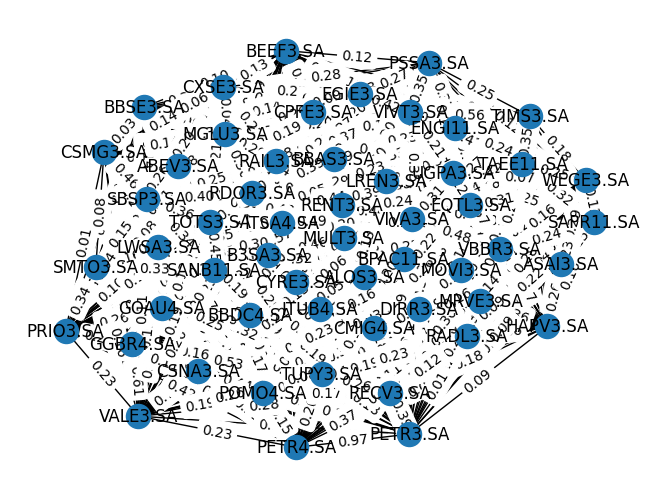

In [ ]:
# Exhibit
pos = nx.spring_layout(G, k=0.5, iterations=50)
nx.draw(G, pos, with_labels=True,)

# Draw edge labels (correlations)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={k: f"{v:.2f}" for k, v in edge_labels.items()}
)

plt.show()

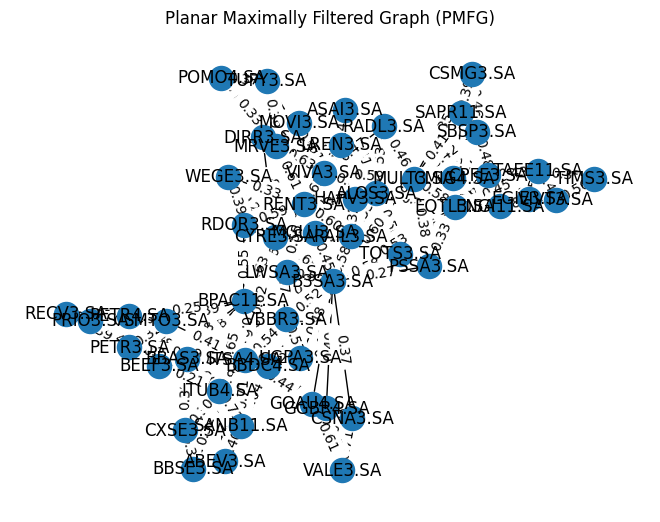

In [ ]:
def get_pmfg(corr_matrix):
    # Make a copy to avoid modifying the original corr_matrix
    temp_corr_matrix = corr_matrix.copy()
    # Clear the index name to prevent collision with column name 'Ticker' during reset_index()
    temp_corr_matrix.index.name = None

    # Organizar todas as correlações em ordem decrescente
    edges = temp_corr_matrix.stack().reset_index()
    edges.columns = ['node1', 'node2', 'weight']

    # Remover auto-correlação (diagonal) e duplicatas (A-B vs B-A)
    edges = edges[edges['node1'] < edges['node2']]
    edges = edges.sort_values(by='weight', ascending=False)

    # Inicializar o Grafo
    G_pmfg = nx.Graph()
    G_pmfg.add_nodes_from(corr_matrix.columns)

    # O limite teórico de arestas para um grafo planar é 3(n-2)
    n = len(corr_matrix.columns)
    max_edges = 3 * (n - 2)

    # Greedy Algorithm: Adiciona a aresta se o grafo continuar sendo planar
    for _, row in edges.iterrows():
        if G_pmfg.number_of_edges() >= max_edges:
            break

        G_pmfg.add_edge(row['node1'], row['node2'], weight=row['weight'])

        # Teste de Planaridade
        is_planar, _ = nx.check_planarity(G_pmfg)

        if not is_planar:
            G_pmfg.remove_edge(row['node1'], row['node2'])

    return G_pmfg

G_pmfg = get_pmfg(corr_matrix)

# Plotagem
pos = nx.spring_layout(G_pmfg)

nx.draw(G_pmfg, pos, with_labels=True)

# Mostrar os valores das correlações nas arestas do PMFG
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G_pmfg.edges(data=True)}
nx.draw_networkx_edge_labels(G_pmfg, pos, edge_labels=edge_labels, font_size=10)

plt.title("Planar Maximally Filtered Graph (PMFG)")
plt.show()

In [ ]:
def calculate_hybrid_measure(G, weight_attr='weight'):
    """
    Calculates the Hybrid Measure P(i) for nodes in a NetworkX graph
    based on the provided Scientific Reports article (2025).

    Args:
        G (nx.Graph): Input graph. Edges must have the specified `weight_attr`
                      representing Pearson correlation (rho), range [-1, 1].
        weight_attr (str): The edge attribute key for correlation.

    Returns:
        dict: A dictionary {node: P(i)} where P(i) is the hybrid measure.
              Small values indicate central nodes; large values indicate peripheral nodes.
    """

    # 1. Create Graphs with Transformed Weights
    # G_sim: Weights = 1 + rho (For Degree, Eigenvector)
    # G_dist: Weights = sqrt(2(1 - rho)) (For Betweenness, Eccentricity, Closeness)

    G_sim = G.copy()
    G_dist = G.copy()

    # Pre-calculate N-1 for normalization
    n = len(G)
    if n <= 1:
        return {node: 0.0 for node in G.nodes()}

    for u, v, data in G.edges(data=True):
        rho = data.get(weight_attr, 0.0)

        # Clip rho to [-1, 1] to avoid math domain errors
        rho = max(-1.0, min(1.0, rho))

        # Transformation 1: Similarity
        w_sim = 1 + rho
        G_sim[u][v]['weight'] = w_sim

        # Transformation 2: Distance
        w_dist = np.sqrt(2 * (1 - rho))
        G_dist[u][v]['weight'] = w_dist

    # Helper to normalize dict values to [0, 1]
    def normalize_centrality(cent_dict):
        values = list(cent_dict.values())
        max_val = max(values) if values else 1.0
        min_val = min(values) if values else 0.0
        denom = max_val - min_val
        if denom == 0:
            return {k: 0.0 for k in cent_dict} # Or 1.0 if all equal? Usually 0 deviation.
        # Standard Min-Max normalization
        return {k: (v - min_val) / denom for k, v in cent_dict.items()}

    # Helper to normalize by Maximum Possible (for absolute scaling if preferred,
    # but min-max is safer for mixed metrics)
    def scale_max(cent_dict, theoretical_max=None):
        vals = np.array(list(cent_dict.values()))
        if theoretical_max:
            mx = theoretical_max
        else:
            mx = vals.max() if len(vals) > 0 else 1.0
        if mx == 0: return {k: 0.0 for k in cent_dict}
        return {k: v / mx for k, v in cent_dict.items()}

    # --- 2. Calculate Unweighted Centralities (u) ---
    # Note: Using standard NX normalizations (0-1)
    dc_u = nx.degree_centrality(G)
    bc_u = nx.betweenness_centrality(G)
    cc_u = nx.closeness_centrality(G)

    try:
        ec_u = nx.eigenvector_centrality(G, max_iter=1000)
    except:
        ec_u = nx.eigenvector_centrality_numpy(G) # Fallback

    # Unweighted Eccentricity
    # Eccentricity: Lower is better. To make "High = Central", we invert.
    try:
        if not nx.is_connected(G):
             # For disconnected, eccentricity is infinite.
             # Standard practice: use max of component or 0 for infinite.
             # We'll compute on largest component or handle components separately?
             # For simplicity, we calculate on components.
             e_vals_u = {}
             for C in (G.subgraph(c).copy() for c in nx.connected_components(G)):
                 e_vals_u.update(nx.eccentricity(C))
        else:
            e_vals_u = nx.eccentricity(G)

        # Invert Eccentricity: C_E = 1 / Eccentricity
        exc_u = {k: (1.0/v if v > 0 else 0.0) for k, v in e_vals_u.items()}
    except Exception as e:
        print(f"Warning: Eccentricity calc failed ({e}), setting to 0")
        exc_u = {n: 0.0 for n in G.nodes()}

    # --- 3. Calculate Weighted Centralities (w) ---

    # Weighted Degree (Strength) (on G_sim)
    deg_w_raw = dict(G_sim.degree(weight='weight'))
    # Normalize weighted degree. Max possible weight is 2. Max degree is 2*(N-1).
    dc_w = {k: v / (2 * (n - 1)) for k, v in deg_w_raw.items()}

    # Weighted Eigenvector (on G_sim)
    try:
        ec_w = nx.eigenvector_centrality(G_sim, weight='weight', max_iter=1000)
    except:
        ec_w = nx.eigenvector_centrality_numpy(G_sim, weight='weight')

    # Weighted Betweenness (on G_dist)
    bc_w = nx.betweenness_centrality(G_dist, weight='weight')

    # Weighted Closeness (on G_dist)
    # NX closeness is 1 / sum(dist). High = Central.
    cc_w = nx.closeness_centrality(G_dist, distance='weight')

    # Weighted Eccentricity (on G_dist)
    try:
        if not nx.is_connected(G_dist):
             e_vals_w = {}
             for C in (G_dist.subgraph(c).copy() for c in nx.connected_components(G_dist)):
                 e_vals_w.update(nx.eccentricity(C, weight='weight'))
        else:
            e_vals_w = nx.eccentricity(G_dist, weight='weight')

        # Invert: C_E = 1 / Eccentricity
        exc_w = {k: (1.0/v if v > 0 else 0.0) for k, v in e_vals_w.items()}
    except:
        exc_w = {n: 0.0 for n in G.nodes()}

    # --- 4. Normalize All to [0, 1] ---
    # This ensures the subtraction in the formula works correctly.
    # We use scale_max to map the raw metric to [0,1] relative to the network's best node.

    C_DC_u = scale_max(dc_u)
    C_DC_w = scale_max(dc_w)
    C_C_u = scale_max(cc_u)
    C_C_w = scale_max(cc_w)

    C_BC_u = scale_max(bc_u)
    C_BC_w = scale_max(bc_w)
    C_EC_u = scale_max(ec_u)
    C_EC_w = scale_max(ec_w)
    C_E_u = scale_max(exc_u)
    C_E_w = scale_max(exc_w)

    # --- 5. Compute Hybrid Measure P(i)  ---
    # Formula:
    # Term 1 (Group of 4): (4 - Sum(DC_w, DC_u, CC_w, CC_u)) / 4
    # Term 2 (Group of 6): (6 - Sum(BC_w, BC_u, E_w, E_u, EC_w, EC_u)) / 6

    P = {}
    for i in G.nodes():
        # Sum Group 1
        sum_group_1 = (C_DC_w.get(i,0) + C_DC_u.get(i,0) +
                       C_C_w.get(i,0) + C_C_u.get(i,0))

        # Sum Group 2
        sum_group_2 = (C_BC_w.get(i,0) + C_BC_u.get(i,0) +
                       C_E_w.get(i,0) + C_E_u.get(i,0) +
                       C_EC_w.get(i,0) + C_EC_u.get(i,0))

        term1 = (sum_group_1 - 4) / (4*n)
        term2 = (sum_group_2 - 6) / (6*n)

        # Total P(i)
        P[i] = term1 + term2

    return P

def get_periphery_nodes(G_pmfg, num_assets):
    # Calcular Node Strength (Grau Ponderado)
    centrality_dict = calculate_hybrid_measure(G_pmfg)

    # Converter para Pandas Series e Ordenar
    centrality_series = pd.Series(centrality_dict, name="Node Strength")

    # Selecionar a Periferia (Menores valores)
    periphery_assets = centrality_series.sort_values(ascending=True)

    tickers = periphery_assets.head(num_assets).index.tolist()
    return tickers

selected_tickers = get_periphery_nodes(G_pmfg, 10)
print("Periphery Assets:")
print(selected_tickers)

Periphery Assets:
['TIMS3.SA', 'RECV3.SA', 'POMO4.SA', 'PRIO3.SA', 'CSMG3.SA', 'VALE3.SA', 'BBSE3.SA', 'BEEF3.SA', 'ABEV3.SA', 'VIVT3.SA']


[*****                 11%                       ]  7 of 64 completed

Iniciando download...


[*********************100%***********************]  64 of 64 completed
ERROR:yfinance:
10 Failed downloads:
ERROR:yfinance:['ELET3.SA', 'BRFS3.SA', 'ARZZ3.SA', 'PETZ3.SA', 'TRPL4.SA', 'STBP3.SA', 'CPLE6.SA', 'JBSS3.SA', 'CRFB3.SA', 'EMBR3.SA']: YFTzMissingError('possibly delisted; no timezone found')


Sucesso! Analisando 54 ativos (de 64 originais).


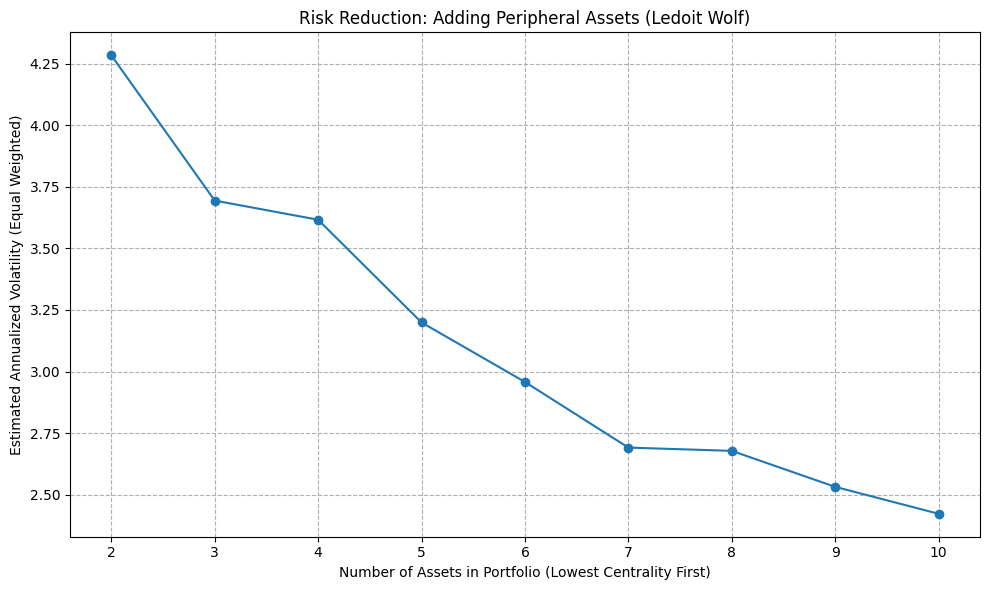

In [ ]:
def calculate_vol_reduction(df_historical_prices, peripheral_tickers_ranked, risk_model=risk_model):
    """
    Calculates the reduction in portfolio volatility as peripheral assets are added,
    using the user's preferred risk model.
    """
    volatilities = []
    nums = []

    # Calculate the global risk matrix using the chosen model for all available assets
    # The risk_models.risk_matrix function expects a DataFrame of prices.
    S_full = risk_models.risk_matrix(df_historical_prices, method=risk_model)

    # Test portfolios from size 2 up to the total number of peripheral assets
    max_num_peripheral_assets = len(peripheral_tickers_ranked)

    for n in range(2, max_num_peripheral_assets + 1): # Iterate from 2 up to max_num_peripheral_assets

        # Select the top 'n' peripheral assets from the ranked list
        current_portfolio_tickers = peripheral_tickers_ranked[:n]

        # Create an equally weighted portfolio (1/N)
        weights = np.ones(n) / n

        # Slice the covariance matrix for these specific assets
        sub_cov = S_full.loc[current_portfolio_tickers, current_portfolio_tickers]

        # Calculate portfolio volatility: sqrt(w.T * S * w)
        # We multiply by sqrt(252) to annualize the result
        daily_vol = np.sqrt(weights.T @ sub_cov @ weights)
        annual_vol = daily_vol * np.sqrt(252)

        volatilities.append(annual_vol)
        nums.append(n)

    return nums, volatilities

# --- EXECUTION ---

# Re-obtain the historical price data specifically for this calculation
# to avoid variable collision with the 'data' dictionary from portfolio performance.
# This ensures `df_historical_prices_for_vol_reduction` is a DataFrame of prices.
df_historical_prices_for_vol_reduction = get_data(tickers, start_past_data, end_past_data)

# 2. Calculate the curve using your chosen models
# Pass the correct historical price DataFrame and the list of selected peripheral tickers.
ns, vols = calculate_vol_reduction(df_historical_prices_for_vol_reduction, selected_tickers, risk_model=risk_model)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(ns, vols, marker='o')

plt.title(f"Risk Reduction: Adding Peripheral Assets ({risk_model.replace('_', ' ').title()})", fontsize=12)
plt.xlabel("Number of Assets in Portfolio (Lowest Centrality First)")
plt.ylabel("Estimated Annualized Volatility (Equal Weighted)")
plt.grid(True, linestyle='--')

# Highlight the "elbow" or specific points if needed
plt.tight_layout()
plt.show()

# **Portfolio Optimization using Efficient Frontier**

In [ ]:
def optimize_portfolio(selected_tickers, start_date, end_date, ret_model=ret_model, risk_model=risk_model):
    """
    Downloads historical stock data, calculates the Efficient Frontier,
    and return the Minimum Variance and Maximum Sharpe portfolios.
    """
    # Download historical data
    df = yf.download(selected_tickers, start=start_date, end=end_date, auto_adjust=True)['Close']

    # Calculate expected returns and risk matrix
    mu = getattr(expected_returns, ret_model)(df)
    S = risk_models.risk_matrix(df, method=risk_model)

    # --- CALCULATION: MINIMUM VARIANCE ---
    ef_min = EfficientFrontier(mu, S)
    weights_min = ef_min.min_volatility()
    perf_min = ef_min.portfolio_performance()

    # --- CALCULATION: MAXIMUM SHARPE ---
    ef_max = EfficientFrontier(mu, S)
    weights_max = ef_max.max_sharpe()
    perf_max = ef_max.portfolio_performance()

    return weights_min, weights_max, perf_min, perf_max

# Re-run optimization
weights_min, weights_max, perf_min, perf_max = optimize_portfolio(selected_tickers, start_past_data, end_past_data, ret_model=ret_model, risk_model=risk_model)

# --- PRINT FORMATTING ---
def format_weights(weights):
    df_w = pd.DataFrame.from_dict(weights, orient='index', columns=['Percentage (%)'])
    df_w['Percentage (%)'] = (df_w['Percentage (%)'] * 100).round(2)
    return df_w.sort_values(by='Percentage (%)', ascending=False)

print("\n")
print("MINIMUM VARIANCE Portfolio:")
print(format_weights(weights_min))
print("\nMAXIMUM SHARPE Portfolio:")
print(format_weights(weights_max))

print("\nHighlighted portfolios metrics:")
print(f"Min Vol -> Return: {perf_min[0]:.4f}, Volatility: {perf_min[1]:.4f}, Sharpe without risk-free return: {perf_min[2]:.4f}")
print(f"Max Sharpe -> Return: {perf_max[0]:.4f}, Volatility: {perf_max[1]:.4f}, Sharpe without risk-free return: {perf_max[2]:.4f}")

# --- PLOTTING ---

df = yf.download(selected_tickers, start=start_past_data, end=end_past_data, auto_adjust=True)['Close']
mu = getattr(expected_returns, ret_model)(df)
S = risk_models.risk_matrix(df, method=risk_model)

fig, ax = plt.subplots()
ef_plot = EfficientFrontier(mu, S)
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

# Add star markers for the specific portfolios
ax.scatter(perf_min[1], perf_min[0], marker="*", s=200, c="blue", label="Min Volatility")
ax.scatter(perf_max[1], perf_max[0], marker="*", s=200, c="red", label="Max Sharpe")

ax.set_title(f"Efficient Frontier ({ret_model} / {risk_model})")
ax.legend()
plt.tight_layout()
plt.show()

[*********************100%***********************]  10 of 10 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['RECV3.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2015-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1262311200, endDate = 1451527200")')


ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.


SolverError: 4

# **Simulation**

In [ ]:
# ---FUNÇÃO AUXILIAR PARA CDI ---
def get_cdi_acumulado(start_date, end_date):
    """
    Busca a taxa DI (CDI) diária na API do Banco Central do Brasil (BCB).
    Divide a requisição em lotes de 5 anos para contornar o limite de 10 anos da API.
    """
    start_dt = pd.to_datetime(start_date)
    end_dt = pd.to_datetime(end_date)

    all_data = []
    current_start = start_dt

    # Faz requisições em blocos de até 5 anos
    while current_start <= end_dt:
        # Define o fim do bloco atual (5 anos ou a data final, o que vier primeiro)
        current_end = min(current_start + pd.DateOffset(years=5), end_dt)

        start_formatted = current_start.strftime('%d/%m/%Y')
        end_formatted = current_end.strftime('%d/%m/%Y')

        url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial={start_formatted}&dataFinal={end_formatted}"

        response = requests.get(url)
        data = response.json()

        if isinstance(data, list) and len(data) > 0:
            all_data.extend(data)
        else:
            print(f"⚠️ Aviso: Sem dados para o período {start_formatted} a {end_formatted}.")

        # O próximo bloco começa um dia após o fim do bloco atual
        current_start = current_end + pd.DateOffset(days=1)

    # Verificação de segurança final
    if not all_data:
        raise ValueError("Falha ao buscar os dados do CDI. Verifique sua conexão ou as datas.")

    # Constrói o DataFrame final com todos os blocos combinados
    df_cdi = pd.DataFrame(all_data)
    df_cdi['data'] = pd.to_datetime(df_cdi['data'], dayfirst=True)
    df_cdi['valor'] = df_cdi['valor'].astype(float) / 100 # Converte de % para decimal

    # Remove possíveis duplicatas, define o índice e ordena cronologicamente
    df_cdi = df_cdi.drop_duplicates(subset=['data'])
    df_cdi.set_index('data', inplace=True)
    df_cdi.sort_index(inplace=True)

    return df_cdi['valor']

In [ ]:
def get_portfolio_performance_data(weights_max, weights_min, start_simulation, end_simulation):
    # Baixa ações do portfólio e os Benchmarks
    df_max_assets = yf.download(list(weights_max.keys()), start=start_simulation, end=end_simulation)['Close']
    df_min_assets = yf.download(list(weights_min.keys()), start=start_simulation, end=end_simulation)['Close']
    df_benchmark = yf.download("^BVSP", start=start_simulation, end=end_simulation)['Close']
    cdi_diario = get_cdi_acumulado(start_simulation, end_simulation)

    # --- CÁLCULO DE RETORNOS ---
    rets_max_assets = df_max_assets.pct_change().dropna()
    rets_min_assets = df_min_assets.pct_change().dropna()
    rets_benchmark = df_benchmark.pct_change().dropna()

    # Alinhar as datas (Portfólio, IBOV e CDI)
    rets_max_assets, rets_benchmark = rets_max_assets.align(rets_benchmark, join='inner', axis=0)
    rets_max_assets, cdi_diario = rets_max_assets.align(cdi_diario, join='inner', axis=0)
    rets_max_assets, rets_min_assets = rets_max_assets.align(rets_min_assets, join='inner', axis=0)

    # --- CÁLCULO DO PORTFÓLIO ---
    w_max_series = pd.Series(weights_max)
    max_portfolio_rets = rets_max_assets.dot(w_max_series)

    w_min_series = pd.Series(weights_min)
    min_portfolio_rets = rets_min_assets.dot(w_min_series)

    # --- NORMALIZAÇÃO (Base 1,00 real) ---
    max_portfolio_value = 1 * (1 + max_portfolio_rets).cumprod()
    min_portfolio_value = 1 * (1 + min_portfolio_rets).cumprod()
    benchmark_value = 1 * (1 + rets_benchmark).cumprod()
    cdi_value = 1 * (1 + cdi_diario).cumprod()

    return {
        "max_portfolio_value": max_portfolio_value,
        "min_portfolio_value": min_portfolio_value,
        "benchmark_value": benchmark_value,
        "cdi_value": cdi_value,
        "max_portfolio_rets": max_portfolio_rets,
        "min_portfolio_rets": min_portfolio_rets,
        "rets_benchmark": rets_benchmark,
        "cdi_diario": cdi_diario,
        "weights_max": weights_max,
        "weights_min": weights_min
    }

def plot_portfolio_performance(data):
    max_portfolio_value = data["max_portfolio_value"]
    min_portfolio_value = data["min_portfolio_value"]
    benchmark_value = data["benchmark_value"]
    cdi_value = data["cdi_value"]

    # --- PLOTAGEM ---
    plt.figure(figsize=(12, 6))

    plt.plot(max_portfolio_value, label="Portfolio (Max Sharpe)", linewidth=2, color="red")
    plt.plot(min_portfolio_value, label="Portfolio (Min volatility)", linewidth=2, color="blue")
    plt.plot(benchmark_value, label="IBOVESPA (Brazilian stocks benchmark)", linewidth=2, color="gray", linestyle="--")
    plt.plot(cdi_value, label="CDI (Fixed income benchmark)", linewidth=2, color="orange", linestyle=":")

    plt.title("Income evolution: strategy's portfolio vs benchmarks (Base 1)", fontsize=14)
    plt.ylabel("Value (R$)")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Destaque de retorno final
    final_max_port = max_portfolio_value.iloc[-1]
    final_min_port = min_portfolio_value.iloc[-1]
    final_bench = benchmark_value.iloc[-1]
    final_cdi = cdi_value.iloc[-1]

    plt.text(max_portfolio_value.index[-1], final_max_port, f" {final_max_port.item():.2f}", color="red", fontweight="bold")
    plt.text(min_portfolio_value.index[-1], final_min_port, f" {final_min_port.item():.2f}", color="blue", fontweight="bold")
    plt.text(benchmark_value.index[-1], final_bench, f" {final_bench.item():.2f}", color="gray", fontweight="bold")
    plt.text(cdi_value.index[-1], final_cdi, f" {final_cdi.item():.2f}", color="orange", fontweight="bold")

    plt.show()

In [ ]:
def print_portfolio_metrics(data, annualization_factor=252):
    """
    Calculates and prints a performance summary table comparing portfolios,
    IBOV, and CDI based on the provided data dictionary.
    """

    # --- HELPER FUNCTIONS ---
    def annualized_return(cumulative_value, periods_per_year=252):
        total_periods = len(cumulative_value)
        total_return = cumulative_value.iloc[-1]
        return total_return ** (periods_per_year / total_periods) - 1

    def max_drawdown(cumulative_series):
        rolling_max = cumulative_series.cummax()
        drawdown = cumulative_series / rolling_max - 1
        return drawdown.min()

    def format_table(df):
        formatted = df.copy()
        pct_cols = ["Annualized Return", "Annualized Vol", "Max Drawdown"]
        for col in pct_cols:
            formatted[col] = formatted[col].map(lambda x: f"{x:.2%}" if pd.notnull(x) else "-")
        formatted["Sharpe Ratio"] = formatted["Sharpe Ratio"].map(lambda x: f"{x:.2f}" if pd.notnull(x) else "-")
        return formatted

    # --- EXTRACT DATA ---
    max_portfolio_rets = data["max_portfolio_rets"]
    min_portfolio_rets = data["min_portfolio_rets"]
    rets_benchmark = data["rets_benchmark"]
    cdi_diario = data["cdi_diario"]

    max_portfolio_value = data["max_portfolio_value"]
    min_portfolio_value = data["min_portfolio_value"]
    benchmark_value = data["benchmark_value"]
    cdi_value = data["cdi_value"]

    # --- CALCULATIONS ---

    # Annualized Volatility
    vol_max = max_portfolio_rets.std() * np.sqrt(annualization_factor)
    vol_min = min_portfolio_rets.std() * np.sqrt(annualization_factor)
    vol_ibov = rets_benchmark.std().item() * np.sqrt(annualization_factor)

    # Annualized Returns
    ret_max_ann = annualized_return(max_portfolio_value)
    ret_min_ann = annualized_return(min_portfolio_value)
    ret_ibov_ann = annualized_return(benchmark_value).item()
    ret_cdi_ann  = annualized_return(cdi_value)

    # Sharpe Ratio (Excess return over CDI)
    excess_max = max_portfolio_rets - cdi_diario
    excess_min = min_portfolio_rets - cdi_diario
    # Ensure indexing for benchmark excess return
    excess_ibov = rets_benchmark.iloc[:, 0] - cdi_diario if isinstance(rets_benchmark, pd.DataFrame) else rets_benchmark - cdi_diario

    sharpe_max = (excess_max.mean() / excess_max.std()) * np.sqrt(annualization_factor)
    sharpe_min = (excess_min.mean() / excess_min.std()) * np.sqrt(annualization_factor)
    sharpe_ibov = (excess_ibov.mean() / excess_ibov.std()) * np.sqrt(annualization_factor)

    # Max Drawdown
    dd_max = max_drawdown(max_portfolio_value)
    dd_min = max_drawdown(min_portfolio_value)
    dd_ibov = max_drawdown(benchmark_value).item()

    # --- CONSTRUCTING THE RESULTS TABLE ---
    metrics_data = {
        "Strategy": ["Max Sharpe", "Min Volatility", "IBOV (Benchmark)", "CDI"],
        "Annualized Return": [ret_max_ann, ret_min_ann, ret_ibov_ann, ret_cdi_ann],
        "Annualized Vol": [vol_max, vol_min, vol_ibov, np.nan],
        "Sharpe Ratio": [sharpe_max, sharpe_min, sharpe_ibov, np.nan],
        "Max Drawdown": [dd_max, dd_min, dd_ibov, np.nan]
    }

    df_metrics = pd.DataFrame(metrics_data).set_index("Strategy")

    print("\n--- PORTFOLIO PERFORMANCE SUMMARY ---")
    print(format_table(df_metrics))

    return df_metrics

In [ ]:
def portfolio_backtesting(tickers, start_past_data, end_past_data, start_simulation, end_simulation, ret_model=ret_model, risk_model=risk_model):
    data_tickers = get_data(tickers, start_past_data, end_past_data)
    corr_matrix = calculate_correlation_matrix(data_tickers)
    G_pmfg = get_pmfg(corr_matrix)
    selected_tickers = get_periphery_nodes(G_pmfg, 10)
    weights_min, weights_max, perf_min, perf_max = optimize_portfolio(selected_tickers, start_past_data, end_past_data, ret_model=ret_model, risk_model=risk_model)
    data_portfolio = get_portfolio_performance_data(weights_max, weights_min, start_simulation, end_simulation)
    plot_portfolio_performance(data_portfolio)
    print_portfolio_metrics(data_portfolio, annualization_factor=252)
    return data_portfolio

# Execution

In [ ]:
# --- Define Tickers with many stocks ---

tickers = [
    # --- AMERICAS (USA & Canada) ---
    "AAPL", "MSFT", "GOOGL", "NVDA",  # US Tech Giants
    "JPM", "GS", "V", "BRK-B",         # US Financials
    "XOM", "CVX",                      # US Energy
    "PG", "KO", "PEP",                 # US Consumer Staples
    "UNH", "PFE",                      # US Healthcare
    "CAT", "BA",                       # US Industrials
    "SHOP.TO", "TD.TO",                # Canada (Tech & Bank)

    # --- BRAZIL (Key Players) ---
    "VALE3.SA", "PETR4.SA", "ITUB4.SA", "BBDC4.SA",
    "WEGE3.SA", "ABEV3.SA", "RENT3.SA",
    "LREN3.SA", "TOTS3.SA",

    # --- EUROPE (UK, Germany, France, Switzerland) ---
    "SHEL.L", "HSBA.L", "AZN.L",       # UK (Energy, Bank, Pharma)
    "SAP.DE", "SIE.DE", "ALV.DE",      # Germany (Tech, Industrial, Insurance)
    "MC.PA", "OR.PA", "TTE.PA",        # France (LVMH/Luxury, L'Oreal, Total)
    "NESN.SW", "NOVN.SW",              # Switzerland (Nestle, Novartis)
    "ASML.AS",                         # Netherlands (Semiconductors)
    "FER.MC",                          # Spain (Infrastructure)

    # --- ASIA & OCEANIA (Japan, Hong Kong, Australia) ---
    "7203.T", "6758.T",                # Japan (Toyota, Sony)
    "9984.T", "8306.T",                # Japan (Softbank, MUFG Bank)
    "0700.HK",                         # Hong Kong (Tencent, Alibaba)
    "1299.HK",                         # Hong Kong (AIA Insurance)
    "BHP.AX", "CBA.AX",                # Australia (Mining, Bank)
    "TSM",                             # Taiwan (TSMC - ADR)
    "HDFCBANK.NS", "RELIANCE.NS",      # India (Bank, Energy/Conglomerate)

    # --- EMERGING MARKETS / OTHERS ---
    "MELI",                            # LatAm (Mercado Libre - US Listed)
    "PBR",                             # Brazil (Petrobras - ADR)
    "GOLD",                            # Gold Mining (Barrick Gold)
    "RIO",                             # Global Mining (Rio Tinto)
]

# --- Time period for past data analysis ---
start_past_data = "2010-01-01"
end_past_data = "2015-12-31"

# --- Returns and risk models ---

# EXPECTED RETURNS MODELS (mu)
# Options:
# - "mean_historical_return": Traditional average daily returns.
# - "ema_historical_return": Exponential moving average (gives more weight to recent prices).
# - "capm_return": Uses the Capital Asset Pricing Model based on market returns.
ret_model = "ema_historical_return"

# RISK MODELS (S)
# Options:
# - "sample_cov": Standard sample covariance matrix (unfiltered noise).
# - "semicovariance": Focuses only on downside risk (volatility of negative returns).
# - "exp_cov": Exponentially weighted; gives more importance to recent volatility.
# - "ledoit_wolf": The standard shrinkage towards the average of all variances.
# - "ledoit_wolf_constant_variance": Shrinks towards a matrix with equal variance for all assets.
# - "ledoit_wolf_single_factor": Shrinks towards a Sharpe-style single-factor market model.
# - "ledoit_wolf_constant_correlation": Shrinks towards a matrix where all assets have the same correlation.
# - "oracle_approximating": OAS method; mathematically superior when assets >> data points.
risk_model = "ledoit_wolf_constant_correlation"

# --- Time period for simulation ---

# Convert string end_past_data into a datetime object
end_past_dt = datetime.strptime(end_past_data, '%Y-%m-%d')

# Add 1 day for the simulation start
start_simulation_dt = end_past_dt + timedelta(days=1)

# Get yesterday's date for the simulation end
end_simulation_dt = datetime.now() - timedelta(days=1)

# Actual time period
start_simulation = start_simulation_dt.strftime('%Y-%m-%d')
end_simulation = end_simulation_dt.strftime('%Y-%m-%d')

[                       0%                       ]

Iniciando download...


[*********************100%***********************]  56 of 56 completed


Sucesso! Analisando 53 ativos (de 56 originais).


[*********************100%***********************]  10 of 10 completed
/usr/local/lib/python3.12/dist-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/tmp/ipykernel_38627/4078435663.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_max_assets = yf.download(list(weights_max.keys()), start=start_simulation, end=end_simulation)['Close']
[*********************100%***********************]  10 of 10 completed
/tmp/ipykernel_38627/4078435663.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_min_assets = yf.download(list(weights_min.keys()), start=start_simulation, end=end_simulation)['Close']
[*********************100%***********************]  10 of 10 completed
/tmp/ipykernel_38627/4078435663.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_benchmark = yf.download("^BVSP", start=start_simulation, end=e

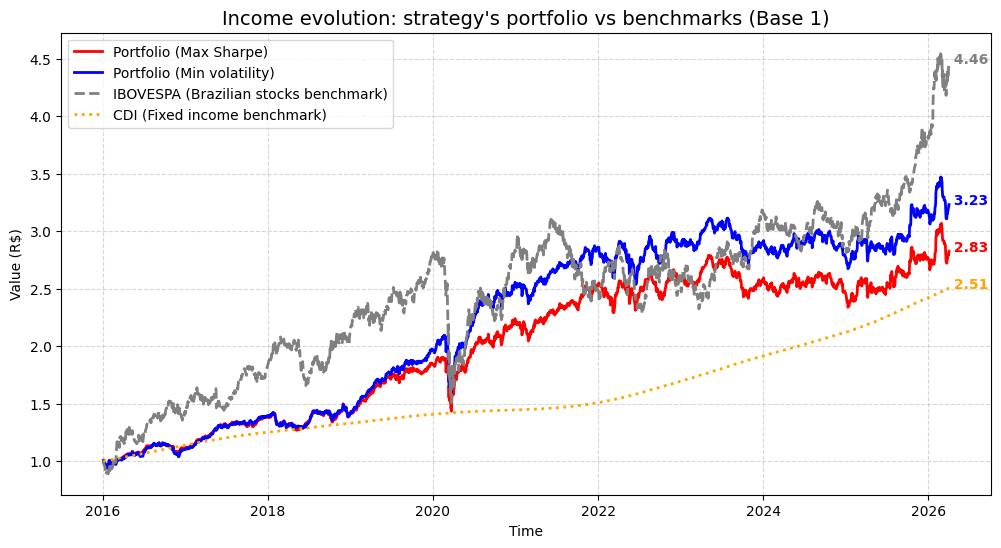


--- PORTFOLIO PERFORMANCE SUMMARY ---
                 Annualized Return Annualized Vol Sharpe Ratio Max Drawdown
Strategy                                                                   
Max Sharpe                  10.83%         13.03%         0.16      -24.67%
Min Volatility              12.31%         12.65%         0.26      -23.85%
IBOV (Benchmark)            15.96%         23.29%         0.36      -46.82%
CDI                          9.52%              -            -            -


In [ ]:
data_portfolio = portfolio_backtesting(tickers, start_past_data, end_past_data, start_simulation, end_simulation, ret_model=ret_model, risk_model=risk_model)

In [ ]:
print("MINIMUM VARIANCE Portfolio:")
print(format_weights(data_portfolio["weights_min"]))
print("\nMAXIMUM SHARPE Portfolio:")
print(format_weights(data_portfolio["weights_max"]))

MINIMUM VARIANCE Portfolio:
             Percentage (%)
PEP                   35.70
NESN.SW               29.28
HDFCBANK.NS            8.26
ABEV3.SA               6.51
WEGE3.SA               6.41
9984.T                 4.65
AAPL                   3.24
TOTS3.SA               3.14
6758.T                 1.59
RENT3.SA               1.23

MAXIMUM SHARPE Portfolio:
             Percentage (%)
PEP                   50.24
NESN.SW               18.16
HDFCBANK.NS           13.56
ABEV3.SA               9.26
6758.T                 5.29
9984.T                 3.49
AAPL                   0.00
RENT3.SA               0.00
TOTS3.SA               0.00
WEGE3.SA               0.00
